In [13]:
class Student:
    def __init__(self, name, roll_no, marks):
        self.name = name
        self.roll_no = roll_no
        self.marks = marks  # dictionary {subject: marks}

    def calculate_total(self):
        return sum(self.marks.values())

    def calculate_average(self):
        return self.calculate_total() / len(self.marks)

    def calculate_grade(self):
        avg = self.calculate_average()
        if avg >= 90:
            return 'A'
        elif avg >= 75:
            return 'B'
        elif avg >= 60:
            return 'C'
        elif avg >= 50:
            return 'D'
        else:
            return 'F'

    def display(self):
        print("\n--- Student Details ---")
        print(f"Name: {self.name}")
        print(f"Roll No: {self.roll_no}")
        print("Marks:", self.marks)
        print(f"Total: {self.calculate_total()}")
        print(f"Average: {self.calculate_average():.2f}")
        print(f"Grade: {self.calculate_grade()}")


class StudentManagementSystem:
    def __init__(self):
        self.students = []

    def add_student(self):
        name = input("Enter student name: ")
        roll_no = input("Enter roll number: ")

        n = int(input("Enter number of subjects: "))
        marks = {}

        for _ in range(n):
            subject = input("Enter subject name: ")
            score = float(input(f"Enter marks for {subject}: "))
            marks[subject] = score

        student = Student(name, roll_no, marks)
        self.students.append(student)
        print("✅ Student added successfully!")

    def display_all(self):
        if not self.students:
            print("No records found.")
            return

        for student in self.students:
            student.display()

    def search_student(self):
        name = input("Enter student name to search: ")
        found = False

        for student in self.students:
            if student.name.lower() == name.lower():
                student.display()
                found = True
                break

        if not found:
            print("❌ Student not found.")


def main():
    system = StudentManagementSystem()

    while True:
        print("\n===== Student Grade Management System =====")
        print("1. Add Student")
        print("2. Display All Students")
        print("3. Search Student")
        print("4. Exit")

        choice = input("Enter your choice: ")

        if choice == '1':
            system.add_student()
        elif choice == '2':
            system.display_all()
        elif choice == '3':
            system.search_student()
        elif choice == '4':
            print("Exiting program...")
            break
        else:
            print("Invalid choice!")


if __name__ == "__main__":
    main()


===== Student Grade Management System =====
1. Add Student
2. Display All Students
3. Search Student
4. Exit


Enter your choice:  4


Exiting program...


In [2]:
import json

class ContactBook:
    def __init__(self, filename="contacts.json"):
        self.filename = filename
        self.contacts = {}
        self.load_contacts()

    def load_contacts(self):
        try:
            with open(self.filename, "r") as file:
                self.contacts = json.load(file)
        except FileNotFoundError:
            self.contacts = {}

    def save_contacts(self):
        with open(self.filename, "w") as file:
            json.dump(self.contacts, file, indent=4)

    def add_contact(self):
        name = input("Enter name: ")
        phone = input("Enter phone number: ")
        email = input("Enter email: ")

        self.contacts[name] = {
            "phone": phone,
            "email": email
        }

        self.save_contacts()
        print("✅ Contact added successfully!")

    def view_contacts(self):
        if not self.contacts:
            print("No contacts found.")
            return

        print("\n--- Contact List ---")
        for name, details in self.contacts.items():
            print(f"\nName: {name}")
            print(f"Phone: {details['phone']}")
            print(f"Email: {details['email']}")

    def search_contact(self):
        name = input("Enter name to search: ")
        if name in self.contacts:
            details = self.contacts[name]
            print("\nContact Found:")
            print(f"Phone: {details['phone']}")
            print(f"Email: {details['email']}")
        else:
            print("❌ Contact not found.")

    def delete_contact(self):
        name = input("Enter name to delete: ")
        if name in self.contacts:
            del self.contacts[name]
            self.save_contacts()
            print("🗑️ Contact deleted.")
        else:
            print("❌ Contact not found.")


def main():
    book = ContactBook()

    while True:
        print("\n===== Contact Book =====")
        print("1. Add Contact")
        print("2. View Contacts")
        print("3. Search Contact")
        print("4. Delete Contact")
        print("5. Exit")

        choice = input("Enter your choice: ")

        if choice == '1':
            book.add_contact()
        elif choice == '2':
            book.view_contacts()
        elif choice == '3':
            book.search_contact()
        elif choice == '4':
            book.delete_contact()
        elif choice == '5':
            print("Exiting...")
            break
        else:
            print("Invalid choice!")


if __name__ == "__main__":
    main()


===== Contact Book =====
1. Add Contact
2. View Contacts
3. Search Contact
4. Delete Contact
5. Exit


Enter your choice:  5


Exiting...


In [3]:
import json

class ToDoList:
    def __init__(self, filename="tasks.json"):
        self.filename = filename
        self.tasks = []
        self.load_tasks()

    def load_tasks(self):
        try:
            with open(self.filename, "r") as file:
                self.tasks = json.load(file)
        except FileNotFoundError:
            self.tasks = []

    def save_tasks(self):
        with open(self.filename, "w") as file:
            json.dump(self.tasks, file, indent=4)

    def add_task(self):
        task = input("Enter new task: ")
        self.tasks.append({"task": task, "completed": False})
        self.save_tasks()
        print("✅ Task added!")

    def view_tasks(self):
        if not self.tasks:
            print("No tasks found.")
            return

        print("\n--- To-Do List ---")
        for i, t in enumerate(self.tasks, start=1):
            status = "✔️" if t["completed"] else "❌"
            print(f"{i}. {t['task']} [{status}]")

    def mark_completed(self):
        self.view_tasks()
        try:
            index = int(input("Enter task number to mark complete: ")) - 1
            if 0 <= index < len(self.tasks):
                self.tasks[index]["completed"] = True
                self.save_tasks()
                print("✅ Task marked as completed!")
            else:
                print("Invalid task number.")
        except ValueError:
            print("Please enter a valid number.")

    def delete_task(self):
        self.view_tasks()
        try:
            index = int(input("Enter task number to delete: ")) - 1
            if 0 <= index < len(self.tasks):
                deleted = self.tasks.pop(index)
                self.save_tasks()
                print(f"🗑️ Deleted task: {deleted['task']}")
            else:
                print("Invalid task number.")
        except ValueError:
            print("Please enter a valid number.")


def main():
    todo = ToDoList()

    while True:
        print("\n===== To-Do List =====")
        print("1. Add Task")
        print("2. View Tasks")
        print("3. Mark Task as Completed")
        print("4. Delete Task")
        print("5. Exit")

        choice = input("Enter your choice: ")

        if choice == '1':
            todo.add_task()
        elif choice == '2':
            todo.view_tasks()
        elif choice == '3':
            todo.mark_completed()
        elif choice == '4':
            todo.delete_task()
        elif choice == '5':
            print("Exiting...")
            break
        else:
            print("Invalid choice!")


if __name__ == "__main__":
    main()


===== To-Do List =====
1. Add Task
2. View Tasks
3. Mark Task as Completed
4. Delete Task
5. Exit


Enter your choice:  5


Exiting...


In [6]:
import tkinter as tk

# Function to update the expression
def press(key):
    entry_var.set(entry_var.get() + str(key))

# Function to evaluate expression
def calculate():
    try:
        result = str(eval(entry_var.get()))
        entry_var.set(result)
    except:
        entry_var.set("Error")

# Function to clear screen
def clear():
    entry_var.set("")

# Main window
root = tk.Tk()
root.title("Simple Calculator")
root.geometry("300x400")
root.resizable(False, False)

entry_var = tk.StringVar()

# Entry field
entry = tk.Entry(root, textvariable=entry_var, font=('Arial', 20), bd=10, relief=tk.RIDGE, justify='right')
entry.pack(fill='both', ipadx=8, ipady=15)

# Buttons layout
buttons = [
    ['7', '8', '9', '/'],
    ['4', '5', '6', '*'],
    ['1', '2', '3', '-'],
    ['0', '.', 'C', '+']
]

# Create buttons
for row in buttons:
    frame = tk.Frame(root)
    frame.pack(expand=True, fill='both')

    for btn in row:
        action = lambda x=btn: press(x) if x != 'C' else clear()
        tk.Button(frame, text=btn, font=('Arial', 16),
                  command=action).pack(side='left', expand=True, fill='both')

# Equal button
equal_frame = tk.Frame(root)
equal_frame.pack(expand=True, fill='both')

tk.Button(equal_frame, text='=', font=('Arial', 16),
          command=calculate, bg='lightblue').pack(expand=True, fill='both')

# Run app
root.mainloop()

In [7]:
import csv
import os

class ExpenseTracker:
    def __init__(self, filename="expenses.csv"):
        self.filename = filename
        self.initialize_file()

    def initialize_file(self):
        if not os.path.exists(self.filename):
            with open(self.filename, "w", newline="") as file:
                writer = csv.writer(file)
                writer.writerow(["Date", "Category", "Amount"])

    def add_expense(self):
        date = input("Enter date (YYYY-MM-DD): ")
        category = input("Enter category (Food, Travel, etc.): ")
        amount = float(input("Enter amount: "))

        with open(self.filename, "a", newline="") as file:
            writer = csv.writer(file)
            writer.writerow([date, category, amount])

        print("✅ Expense added successfully!")

    def view_expenses(self):
        with open(self.filename, "r") as file:
            reader = csv.reader(file)
            print("\n--- Expense Records ---")
            for row in reader:
                print("{:<12} {:<15} {:<10}".format(*row))

    def total_expense(self):
        total = 0
        with open(self.filename, "r") as file:
            reader = csv.DictReader(file)
            for row in reader:
                total += float(row["Amount"])

        print(f"\n💰 Total Expense: {total:.2f}")


def main():
    tracker = ExpenseTracker()

    while True:
        print("\n===== Expense Tracker =====")
        print("1. Add Expense")
        print("2. View Expenses")
        print("3. Show Total Expense")
        print("4. Exit")

        choice = input("Enter your choice: ")

        if choice == '1':
            tracker.add_expense()
        elif choice == '2':
            tracker.view_expenses()
        elif choice == '3':
            tracker.total_expense()
        elif choice == '4':
            print("Exiting...")
            break
        else:
            print("Invalid choice!")


if __name__ == "__main__":
    main()


===== Expense Tracker =====
1. Add Expense
2. View Expenses
3. Show Total Expense
4. Exit


Enter your choice:  4


Exiting...


In [12]:
import random
import string

class PasswordGenerator:
    def __init__(self):
        self.characters = (
            string.ascii_letters +   # a-z + A-Z
            string.digits +          # 0-9
            string.punctuation       # special characters
        )

    def generate_password(self, length):
        password = ''.join(random.choice(self.characters) for _ in range(length))
        return password


def main():
    print("===== Password Generator =====")

    try:
        length = int(input("Enter password length: "))

        if length <= 0:
            print("Length must be positive.")
            return

        generator = PasswordGenerator()
        password = generator.generate_password(length)

        print(f"\n🔐 Generated Password: {password}")

    except ValueError:
        print("Please enter a valid number.")


if __name__ == "__main__":
    main()

===== Password Generator =====


Enter password length:  3



🔐 Generated Password: zL}


In [8]:
import string

class TextAnalyzer:
    def __init__(self, text):
        self.text = text
        self.cleaned_words = self.clean_text()

    def clean_text(self):
        # Remove punctuation and convert to lowercase
        translator = str.maketrans('', '', string.punctuation)
        cleaned = self.text.translate(translator).lower()
        return cleaned.split()

    def word_count(self):
        return len(self.cleaned_words)

    def longest_word(self):
        if not self.cleaned_words:
            return None
        return max(self.cleaned_words, key=len)

    def word_frequency(self):
        freq = {}
        for word in self.cleaned_words:
            freq[word] = freq.get(word, 0) + 1
        return freq

    def display_analysis(self):
        print("\n--- Text Analysis ---")
        print(f"Total Words: {self.word_count()}")
        print(f"Longest Word: {self.longest_word()}")

        print("\nWord Frequency:")
        for word, count in self.word_frequency().items():
            print(f"{word}: {count}")


def main():
    print("===== Text Analyzer =====")
    text = input("Enter your text:\n")

    analyzer = TextAnalyzer(text)
    analyzer.display_analysis()


if __name__ == "__main__":
    main()

===== Text Analyzer =====


Enter your text:
 hihiiji



--- Text Analysis ---
Total Words: 1
Longest Word: hihiiji

Word Frequency:
hihiiji: 1


In [9]:
class QuizApp:
    def __init__(self):
        # Dictionary format:
        # question: (options_dict, correct_option)
        self.questions = {
            "What is the capital of France?": (
                {"a": "Berlin", "b": "Madrid", "c": "Paris", "d": "Rome"},
                "c"
            ),
            "Which language is used for web apps?": (
                {"a": "Python", "b": "JavaScript", "c": "C++", "d": "Java"},
                "b"
            ),
            "What is 5 + 3?": (
                {"a": "5", "b": "8", "c": "10", "d": "6"},
                "b"
            ),
            "Which planet is known as Red Planet?": (
                {"a": "Earth", "b": "Mars", "c": "Jupiter", "d": "Venus"},
                "b"
            )
        }

    def start_quiz(self):
        score = 0
        total = len(self.questions)

        print("\n===== Quiz Started =====")

        for question, (options, correct) in self.questions.items():
            print(f"\n{question}")
            for key, value in options.items():
                print(f"{key}) {value}")

            answer = input("Enter your answer (a/b/c/d): ").lower()

            if answer == correct:
                print("✅ Correct!")
                score += 1
            else:
                print(f"❌ Wrong! Correct answer is: {correct}) {options[correct]}")

        print("\n===== Quiz Finished =====")
        print(f"Your Score: {score}/{total}")
        print(f"Percentage: {(score/total)*100:.2f}%")

        if score == total:
            print("🏆 Excellent!")
        elif score >= total/2:
            print("👍 Good job!")
        else:
            print("📘 Keep practicing!")


def main():
    quiz = QuizApp()
    quiz.start_quiz()


if __name__ == "__main__":
    main()


===== Quiz Started =====

What is the capital of France?
a) Berlin
b) Madrid
c) Paris
d) Rome


Enter your answer (a/b/c/d):  c


✅ Correct!

Which language is used for web apps?
a) Python
b) JavaScript
c) C++
d) Java


Enter your answer (a/b/c/d):  b


✅ Correct!

What is 5 + 3?
a) 5
b) 8
c) 10
d) 6


Enter your answer (a/b/c/d):  b


✅ Correct!

Which planet is known as Red Planet?
a) Earth
b) Mars
c) Jupiter
d) Venus


Enter your answer (a/b/c/d):  b


✅ Correct!

===== Quiz Finished =====
Your Score: 4/4
Percentage: 100.00%
🏆 Excellent!


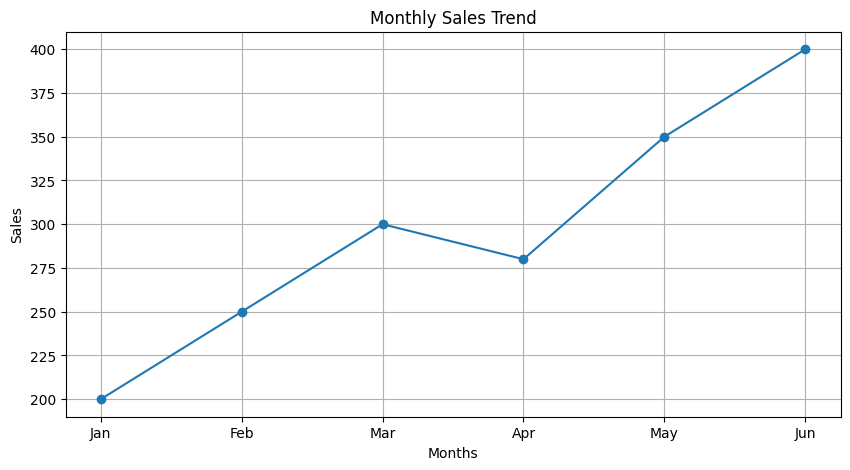

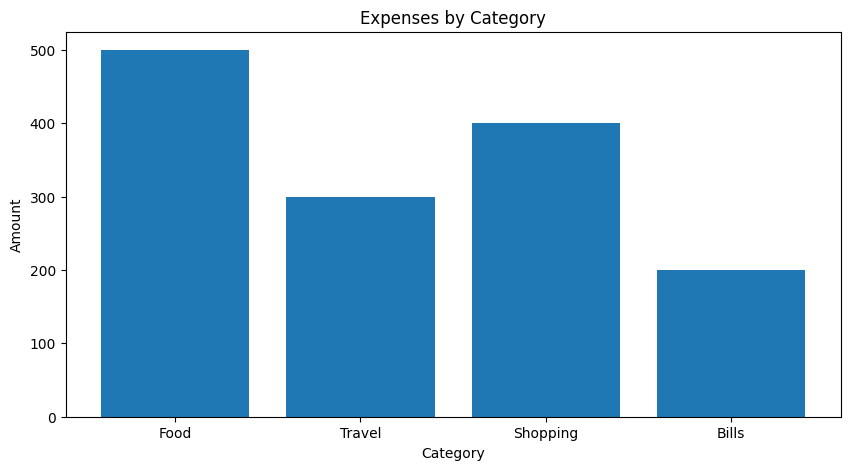

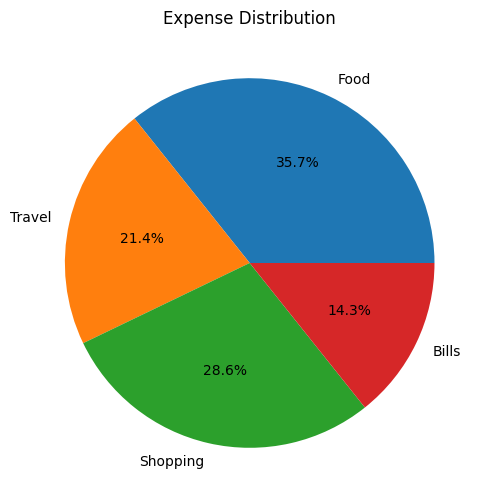

In [10]:
import matplotlib.pyplot as plt

# Sample dataset (Monthly Sales)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = [200, 250, 300, 280, 350, 400]

# Category-wise expenses
categories = ["Food", "Travel", "Shopping", "Bills"]
expenses = [500, 300, 400, 200]

# ----- Line Chart (Sales Trend) -----
plt.figure(figsize=(10, 5))
plt.plot(months, sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.grid()

plt.show()

# ----- Bar Chart (Category Comparison) -----
plt.figure(figsize=(10, 5))
plt.bar(categories, expenses)
plt.title("Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.show()

# ----- Pie Chart (Expense Distribution) -----
plt.figure(figsize=(6, 6))
plt.pie(expenses, labels=categories, autopct='%1.1f%%')
plt.title("Expense Distribution")

plt.show()

In [11]:
import json
import os

class Library:
    def __init__(self, filename="library.json"):
        self.filename = filename
        self.books = []
        self.load_books()

    def load_books(self):
        if os.path.exists(self.filename):
            with open(self.filename, "r") as file:
                self.books = json.load(file)
        else:
            self.books = []

    def save_books(self):
        with open(self.filename, "w") as file:
            json.dump(self.books, file, indent=4)

    def add_book(self):
        title = input("Enter book title: ")
        author = input("Enter author name: ")

        book = {
            "title": title,
            "author": author,
            "issued": False
        }

        self.books.append(book)
        self.save_books()
        print("✅ Book added successfully!")

    def view_books(self):
        if not self.books:
            print("No books available.")
            return

        print("\n--- Library Books ---")
        for i, book in enumerate(self.books, start=1):
            status = "Issued" if book["issued"] else "Available"
            print(f"{i}. {book['title']} by {book['author']} [{status}]")

    def issue_book(self):
        self.view_books()
        try:
            index = int(input("Enter book number to issue: ")) - 1
            if 0 <= index < len(self.books):
                if not self.books[index]["issued"]:
                    self.books[index]["issued"] = True
                    self.save_books()
                    print("📖 Book issued successfully!")
                else:
                    print("❌ Book already issued.")
            else:
                print("Invalid choice.")
        except ValueError:
            print("Enter a valid number.")

    def return_book(self):
        self.view_books()
        try:
            index = int(input("Enter book number to return: ")) - 1
            if 0 <= index < len(self.books):
                if self.books[index]["issued"]:
                    self.books[index]["issued"] = False
                    self.save_books()
                    print("✅ Book returned successfully!")
                else:
                    print("❌ This book was not issued.")
            else:
                print("Invalid choice.")
        except ValueError:
            print("Enter a valid number.")


def main():
    library = Library()

    while True:
        print("\n===== Library Management System =====")
        print("1. Add Book")
        print("2. View Books")
        print("3. Issue Book")
        print("4. Return Book")
        print("5. Exit")

        choice = input("Enter your choice: ")

        if choice == '1':
            library.add_book()
        elif choice == '2':
            library.view_books()
        elif choice == '3':
            library.issue_book()
        elif choice == '4':
            library.return_book()
        elif choice == '5':
            print("Exiting...")
            break
        else:
            print("Invalid choice!")


if __name__ == "__main__":
    main()


===== Library Management System =====
1. Add Book
2. View Books
3. Issue Book
4. Return Book
5. Exit


Enter your choice:  5


Exiting...
